# Cardiovascular Disease Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether a person has cardiovascular disease or not.

In [44]:
import pandas as pd
import numpy as np
CardiovascularData=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/Cardiovascular Disease/health_data_Cardio.csv",
                               encoding='latin')
print('Before deleting repeated rows ',CardiovascularData.shape)
CardiovascularData.drop_duplicates(inplace=True) 
print('After deleting repeated rows ',CardiovascularData.shape)
CardiovascularData.head()

Before deleting repeated rows  (70000, 14)
After deleting repeated rows  (70000, 14)


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


### Rejected Useless Columns:['Unnamed: 0','id']

### Target Variable is cardio

## Exploratory Data Analysis

<Axes: xlabel='cardio'>

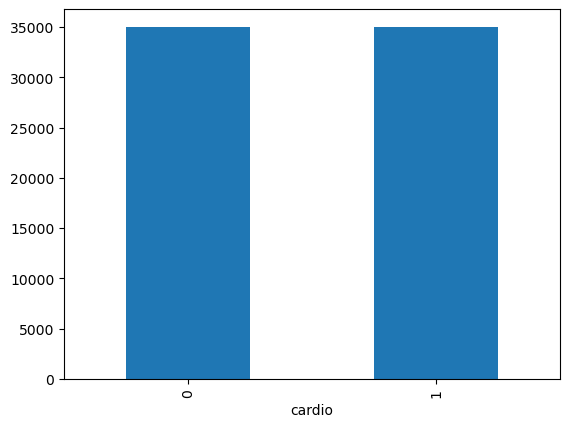

In [45]:
CardiovascularData.groupby('cardio').size().plot(kind='bar')

In [46]:
CardiovascularData.nunique()

Unnamed: 0     70000
id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

In [47]:
CardiovascularData.columns

Index(['Unnamed: 0', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi',
       'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

### CategoricalColumns:['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

### ContinousColumns:['age','height', 'weight', 'ap_hi', 'ap_lo']

In [48]:
CardiovascularData.drop(['Unnamed: 0','id'],axis=1,inplace=True)

In [49]:
CardiovascularData.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


In [50]:
CardiovascularData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


In [51]:
CardiovascularData.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


### Uni Variate Analysis by Bar Charts

IndexError: index 6 is out of bounds for axis 0 with size 6

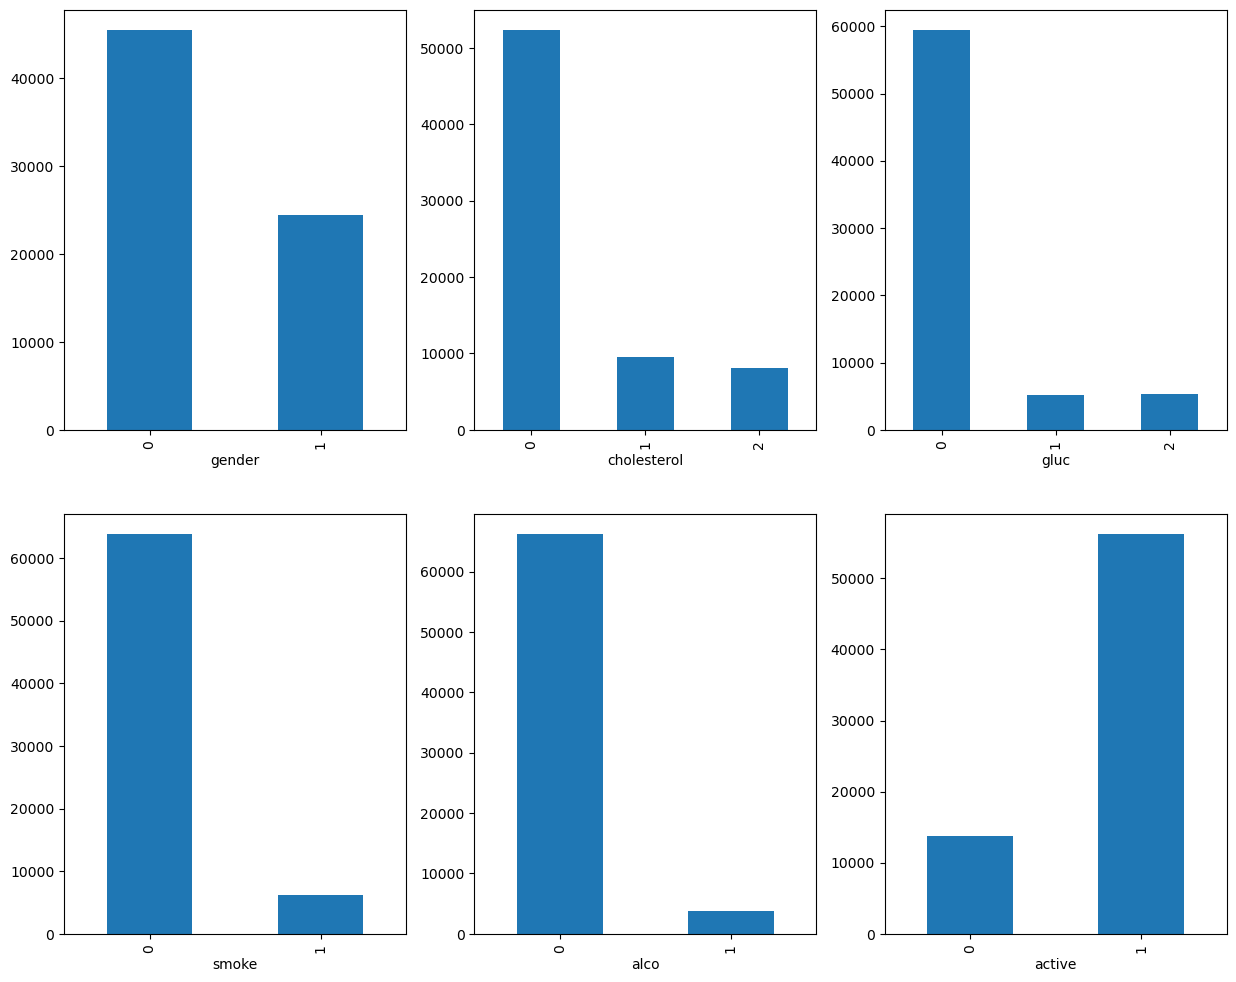

In [52]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    CardiovascularData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

### No need of Treating Imbalance

## Uni Variate Analysis by Histogram

In [ ]:
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
CardiovascularData[ContinousColumns].hist(bins=20,figsize=(15,12))

### No need of  Outlier Treatment

In [ ]:
CardiovascularData.isnull().sum()

### No need of Missing Value Treatment

## Continous Vs Categorical Bivariate Analysis by Box Plots

In [ ]:
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousColumns,range(len(ContinousColumns))):
    CardiovascularData.boxplot(column=cols,by='cardio',ax=subplots[no_of_cols])
    

## Statistical Feature Selection by Anova Function

In [ ]:
targetVariable='cardio'
inpData='CardiovascularData'
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
def functionAnova(inpData,ContinousColumns,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in ContinousColumns:
        CategoricalGroupLists=inpData.groupby('cardio')[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is correlated with Cardio and P value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with Cardio and P value is:',AnovaResults[1])
    return (SelectedPredictors)  
functionAnova(CardiovascularData,ContinousColumns,targetVariable)

## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

In [ ]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12)) 
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    crosstabresults=pd.crosstab(columns=CardiovascularData['cardio'],index=CardiovascularData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])

## Statistical Feature Selection by Chi2 Function

In [ ]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active']
targetVariable='cardio'
def Chi2_function(inpData,cols,targetVariable):
    SelectedPredictors=[]
    from scipy.stats import chi2_contingency
    for cols in CategoricalColumns:
        crosstabresults=pd.crosstab(columns=inpData['cardio'],index=inpData[cols])
        chi2_results=chi2_contingency(crosstabresults)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with cardio and P values is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with cardio and P values is:',chi2_results[1])
    return SelectedPredictors
    
Chi2_function(CardiovascularData,cols,targetVariable) 
        


    

## Selecting final predictors for Machine Learning

In [ ]:
SelectedColumns=['gender', 'cholesterol', 'gluc', 'smoke', 'active','age', 'height', 'weight', 'ap_hi', 'ap_lo']
DataForMLCardiovascularData=CardiovascularData[SelectedColumns]
DataForMLCardiovascularData.to_pickle('CardiovascularData.pkl')
DataForMLCardiovascularData=pd.read_pickle('CardiovascularData.pkl')

DataForMLCardiovascularData['cardio']=CardiovascularData['cardio']
DataForMLCardiovascularData.head()

## Splitting the data into Training and Testing sample

In [ ]:
predictors=['gender', 'cholesterol', 'gluc', 'smoke', 'active','age', 'height', 'weight', 'ap_hi', 'ap_lo']
#predictors=[ 'cholesterol',  'age',   'ap_hi', ]
targetVariable='cardio'
X=DataForMLCardiovascularData[predictors].values
y=DataForMLCardiovascularData[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
X_train[0:4]

In [ ]:
y_train[0:4]

In [ ]:
DataForMLCardiovascularData.info()

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=13,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction =LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction, average='weighted')
print('Sample Test Accuracy:',np.round((F1_Score),2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Average Accuracy of the Model:',np.mean(AccuracyValues))

## Decision Tree

In [ ]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=6,criterion='gini')
DTree=clf.fit(X,y)
prediction=DTree.predict(X_test)
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('SampleDataAccuracy:',np.round((F1_Score),2))
from sklearn.model_selection import cross_val_score
AccuracyValue=cross_val_score(DTree,X,y,cv=6,scoring='f1_weighted')
print(AccuracyValue) 
print('Final Average Accuracy of the Model:',np.mean(AccuracyValue))

## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,criterion='entropy', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score

y_prob = RF.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


OOBScore = RF.oob_score_

print("OOB Score:", round(OOBScore,2)*100,'%')

OOBError = 1 - OOBScore

print("OOB Error:", round(OOBError,2)*100,'%')


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      7092
           1       0.75      0.69      0.72      6908

    accuracy                           0.73     14000
   macro avg       0.

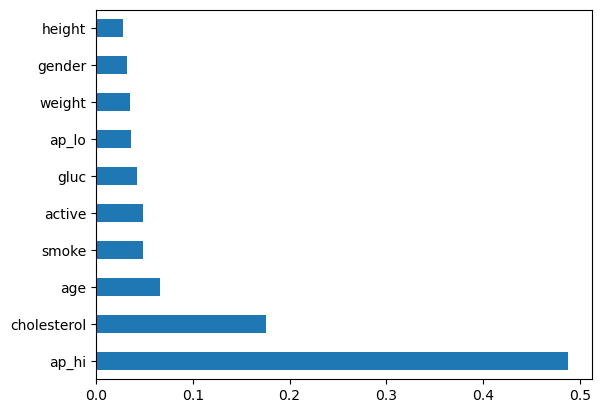

In [55]:
###### Xgboost Classification in Python #######
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=6, learning_rate=0.08, n_estimators=500, objective='binary:logistic', booster='gbtree')

#Printing all the parameters of XGBoost
print(clf)

#Creating the model on Training Data

XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))

print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=15),
                   learning_rate=0.01, n_estimators=500)
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      7092
           1       0.75      0.68      0.71      6908

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000

[[5522 1570]
 [2245 4663]]


,age,gender,cholesterol,gluc,smoke,active,age,height,weight,ap_hi,ap_lo,TargetColumn,Prediction
0,16041.0,0.0,0.0,0.0,0.0,1.0,16041.0,165.0,60.0,120.0,80.0,0,0
1,18244.0,0.0,0.0,0.0,0.0,1.0,18244.0,158.0,68.0,124.0,80.0,0,0
2,17550.0,0.0,0.0,0.0,0.0,1.0,17550.0,162.0,90.0,140.0,90.0,0,1
3,16715.0,0.0,1.0,0.0,0.0,0.0,16715.0,160.0,66.0,90.0,60.0,1,0
4,22545.0,0.0,2.0,0.0,0.0,1.0,22545.0,174.0,64.0,110.0,80.0,1,0


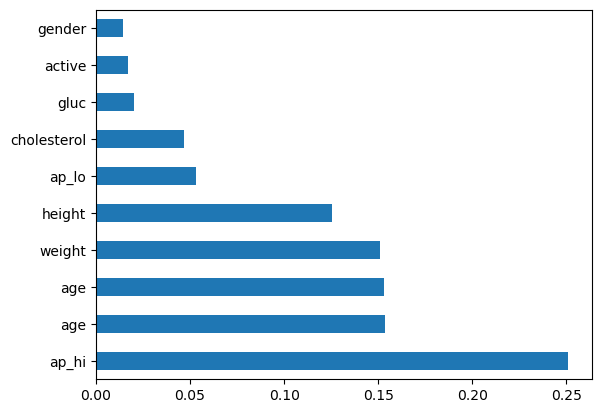

In [24]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=15)
clf = AdaBoostClassifier(n_estimators=500, estimator=DTC ,learning_rate=0.01)
 
#Printing all the parameters of Adaboost
print(clf)

#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head() 

# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [39]:
NewData=pd.DataFrame(data=[
[0,1,0,0,1,18393,168,62,110,80],
[1,2,0,0,1,20228,156,85,140,90],
[0,2,0,0,0,18857,165,64,130,70],
[1,0,0,0,1,17623,169,82,150,100],
[0,0,0,0,0,17474,156,56,100,60],
[1,1,1,0,1,19500,172,78,120,80],
[0,0,0,0,1,18200,160,59,110,70],
[1,2,1,1,0,21050,175,92,160,100],
[0,1,0,0,1,17890,162,68,120,80],
[1,0,0,1,1,19345,180,85,130,85],
[0,2,0,0,0,20560,158,74,140,90],
[1,1,1,0,1,18780,170,79,125,80],
[0,0,0,0,1,17250,155,52,105,65],
[1,2,1,1,0,21540,178,95,170,110],
[0,1,0,0,1,18120,163,60,115,75],
[1,0,0,1,1,19980,182,88,135,85],
[0,2,1,0,0,20870,159,76,145,95],
[1,1,0,0,1,19010,174,81,120,80],
[0,0,0,0,1,17560,157,54,110,70],
[1,2,1,1,0,22000,185,98,180,120],
[0,1,0,0,1,18450,164,63,118,78],
[1,0,0,1,1,19730,177,84,128,82],
[0,2,1,0,0,20640,160,73,142,92],
[1,1,0,0,1,19150,173,80,122,80],
[0,0,0,0,1,17190,154,51,102,64],
[1,2,1,1,0,21480,179,94,168,108],
[0,1,0,0,1,18070,161,58,114,74],
[1,0,0,1,1,19820,181,87,132,84],
[0,2,1,0,0,20790,158,75,146,96],
[1,1,0,0,1,19240,176,82,124,82]
], columns=predictors)
NewData 

,gender,cholesterol,gluc,smoke,active,age,height,weight,ap_hi,ap_lo
0,0,1,0,0,1,18393,168,62,110,80
1,1,2,0,0,1,20228,156,85,140,90
2,0,2,0,0,0,18857,165,64,130,70
3,1,0,0,0,1,17623,169,82,150,100
4,0,0,0,0,0,17474,156,56,100,60
5,1,1,1,0,1,19500,172,78,120,80
6,0,0,0,0,1,18200,160,59,110,70
7,1,2,1,1,0,21050,175,92,160,100
8,0,1,0,0,1,17890,162,68,120,80
9,1,0,0,1,1,19345,180,85,130,85


In [40]:
newX=NewData.values

In [41]:
XGB.predict(newX)

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0])

In [42]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [43]:
GenerateSurvialPred(inpData=NewData)

,gender,cholesterol,gluc,smoke,active,age,height,weight,ap_hi,ap_lo,Prediction
0,0,1,0,0,1,18393,168,62,110,80,0
1,1,2,0,0,1,20228,156,85,140,90,1
2,0,2,0,0,0,18857,165,64,130,70,1
3,1,0,0,0,1,17623,169,82,150,100,1
4,0,0,0,0,0,17474,156,56,100,60,0
5,1,1,1,0,1,19500,172,78,120,80,0
6,0,0,0,0,1,18200,160,59,110,70,0
7,1,2,1,1,0,21050,175,92,160,100,1
8,0,1,0,0,1,17890,162,68,120,80,0
9,1,0,0,1,1,19345,180,85,130,85,0
